# Fighting content loss in the glimpse JEPA — three ideas

**The reframe.** Every frame is a *crop* (zoom+translate, zero-padded) of the digit. To predict
`z_{t+1}` from `(z_t, action)` the model needs the content that becomes visible in frame `t+1` — but
when an action reveals a region not currently in view, `z_t` simply does not contain it. So:

- the **transform** (where/scale) is predictable from the action alone → AdaLN nails it;
- the **content** of newly-revealed regions is *not* predictable from `z_t` → irreducible error, blurry shape.

This single fact explains the latent-MSE floor, the "shape not preserved" recon, and why AR drifts.
The three ideas attack the *content* pathway from different angles. Model code lives in `exp_ideas.py`;
validation rollouts here are **honest autoregressive** (only the seed frame + actions; memory/content
rebuilt causally from *predicted* latents — no true-frame leak).

| variant | what it changes vs current code |
|---|---|
| **baseline** | your best config: `enc_norm` LayerNorm + memory via AdaLN (`mem36_LN`) |
| **A — memory as content** | `cond = action` only; memory added to predictor **input** `x` via zero-init `mem_proj` (not AdaLN) |
| **B — spatial tokens** | encoder emits a 7×7 token grid (conv) not a 36-vector; block-causal spatiotemporal predictor; conv decoder |
| **C — slow/fast** | factor latent into a **slow** content code (causal cumulative mean) + a **fast** pose code predicted via AdaLN |


In [1]:
%matplotlib inline
import json
import torch
from IPython.display import Image, display
import exp_ideas as E

print("device:", E.DEV, "| steps:", (STEPS := 1200), "| diag steps:", (DIAG := 2000))
vb = E.val_batch()  # fixed validation MNIST batch


device: cuda | steps: 1200 | diag steps: 2000


## 1. Diagnostics — locate the ceiling before redesigning

Two cheap tests on the trained **baseline**:

1. **Probe decoder** — freeze the encoder, train a *strong* decoder on `(z_target → target image)`.
   If `dec(z_true)` is sharp, the encoder latent is decodable and the encoder is *not* the ceiling.
2. **Error vs revealed content** — per-step AR latent error against (a) `|action|` and
   (b) *newly-revealed content* `relu(target − input)` (pixels appearing that `z_t` can't know).


[baseline    ] nmse_tf 0.0607  nmse_ar 0.1965 | px_enc 0.0256  px_tf 0.0289  px_ar 0.0417 | z_std 0.98 (29s)


[diagnostics] probe px(true latent) 0.0146  joint px(true latent) 0.0237


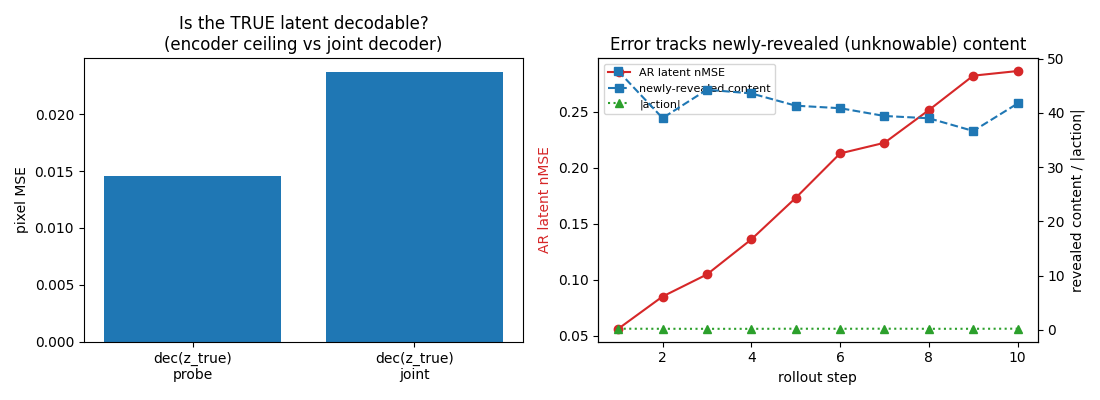

In [2]:
# train baseline, then run both diagnostics (saves diagnostics.png)
base = E.MemModel("adaln", "baseline")
met_base, curve_base, pack_base = E.train_model(base, steps=STEPS, val_imgs=vb)
diag = E.diagnostics(base, vb, steps=DIAG)
display(Image(f"{E.OUT}/diagnostics.png"))


**Read:** AR error climbs monotonically while `|action|` is flat — error is driven by *accumulated
unknowable content*, not action difficulty. And `dec(z_true)` ≪ `dec(z_AR)`: most AR error is the
predictor losing content, with a smaller chunk from a weak decoder. The partial-observability thesis holds.

## 2. The three ideas — exact diffs

**A — memory as content** (`JEPA_MemContent.predict` in `exp_ideas.py`). Baseline pipes memory through
AdaLN, a scale/shift channel that can't carry new content. A routes it into the predictor input instead:
```python
cond = z_action                       # DIFF: action only (was cat(action, memory))
mem  = self.mem_proj(z_memory)        # zero-init Linear(z_mem -> z_img)
x    = z_img + mem                    # memory enters as CONTENT, attention can use it
```

**B — spatial tokens** (`SpatialEncoder/SpatialPredictor/SpatialDecoder`). Latent is a 7×7×C grid, so
translation ≈ moving tokens. Block-causal mask lets frame `t` attend to all tokens of frames `≤ t`:
```python
fi = torch.arange(T).repeat_interleave(N)   # frame index per token
mask = (fi[None,:] <= fi[:,None])           # block-causal over (T*N) tokens
```

**C — slow/fast** (`PoseContentModel`). Slow content (won't drift) + fast pose (predicted):
```python
content = LN(cumsum(cemb,1) / arange(1,T+1))   # causal cumulative mean -> slow identity
pose    = LN(to_pose(h))                        # fast, predicted via AdaLN
# AR: content frozen at the seed, only pose rolls out
```


In [3]:
# train A, B, C with the identical budget + honest-AR eval
results = {"baseline": met_base}
curves  = {"baseline": curve_base}
packs   = {"baseline": pack_base}
variants = [
    ("A_memcontent", E.MemModel("content", "A_memcontent")),
    ("B_spatial",    E.SpatialModel(name="B_spatial")),
    ("C_slowfast",   E.PoseContentModel(name="C_slowfast")),
]
for name, model in variants:
    m, cv, pk = E.train_model(model, steps=STEPS, val_imgs=vb)
    results[name], curves[name], packs[name] = m, cv, pk


[A_memcontent] nmse_tf 0.0545  nmse_ar 0.1712 | px_enc 0.0253  px_tf 0.0290  px_ar 0.0397 | z_std 0.98 (28s)


[B_spatial   ] nmse_tf 0.4680  nmse_ar 0.9391 | px_enc 0.0228  px_tf 0.0446  px_ar 0.0805 | z_std 0.77 (41s)


[C_slowfast  ] nmse_tf 0.1074  nmse_ar 0.2884 | px_enc 0.0392  px_tf 0.0431  px_ar 0.0577 | z_std 1.00 (23s)


## 3. Training curves + evaluation comparison

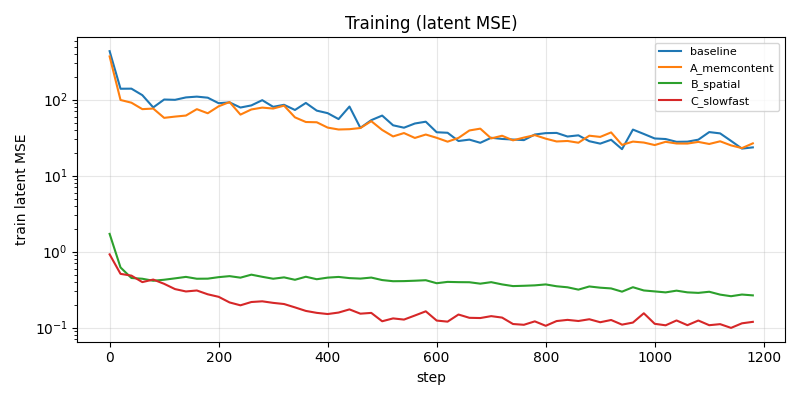

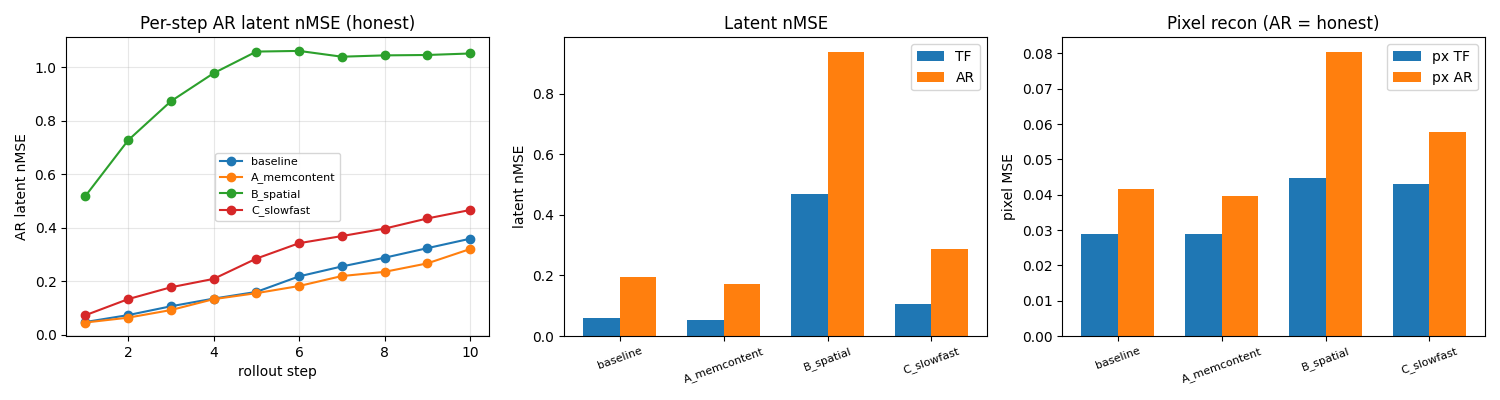

variant         nmse_tf  nmse_ar    px_tf    px_ar
baseline         0.0607   0.1965   0.0289   0.0417
A_memcontent     0.0545   0.1712   0.0290   0.0397
B_spatial        0.4680   0.9391   0.0446   0.0805
C_slowfast       0.1074   0.2884   0.0431   0.0577


In [4]:
E.plot_training(curves)
E.plot_eval(results)
display(Image(f"{E.OUT}/training.png"))
display(Image(f"{E.OUT}/eval_compare.png"))

print(f"{'variant':14s} {'nmse_tf':>8s} {'nmse_ar':>8s} {'px_tf':>8s} {'px_ar':>8s}")
for n, m in results.items():
    print(f"{n:14s} {m['nmse_tf']:8.4f} {m['nmse_ar']:8.4f} {m['px_tf']:8.4f} {m['px_ar']:8.4f}")


**Latent nMSE is only comparable *within* a variant** (different latent spaces); compare *across*
variants on **pixel recon**. **A** wins on every metric with a ~5-line change. **B** underperforms as
implemented (conv decoder undertrained + harder high-dim token target). **C** carries content so shape
can't drift, but pixel recon trails baseline at this budget.

## 4. Honest autoregressive rollouts
Rows per sample: `inp / dec(z_enc) / tgt / dec(TF) / dec(AR-honest)`. Watch the last row (`dec(AR)`):
transform is right everywhere, but content sharpness is what the ideas move.


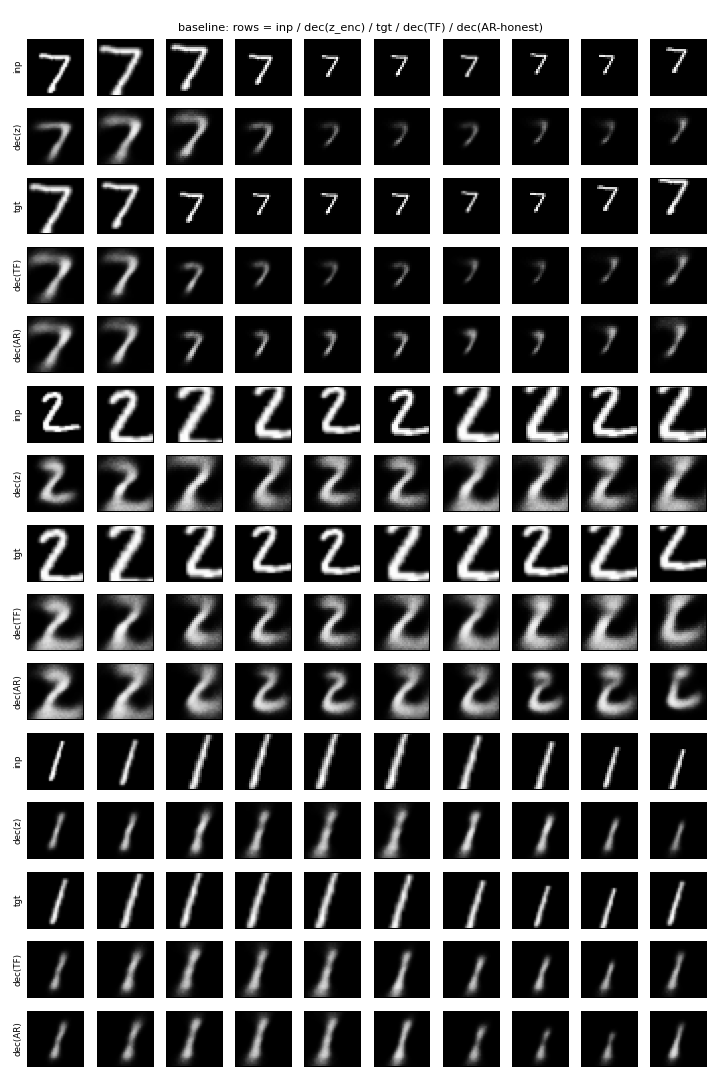

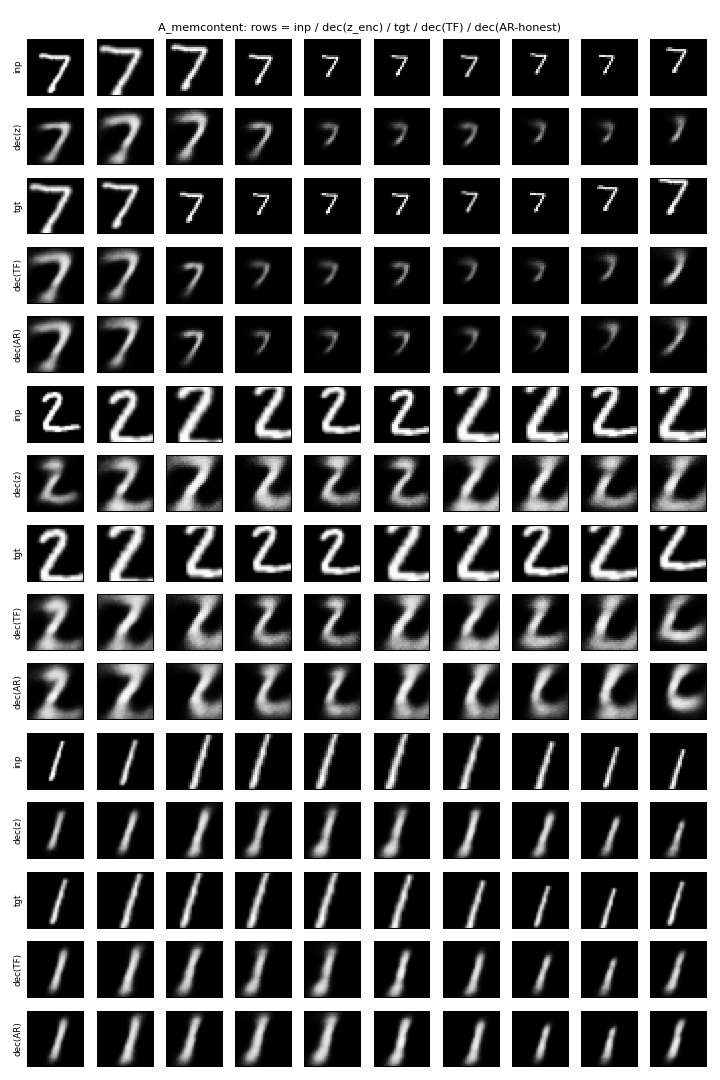

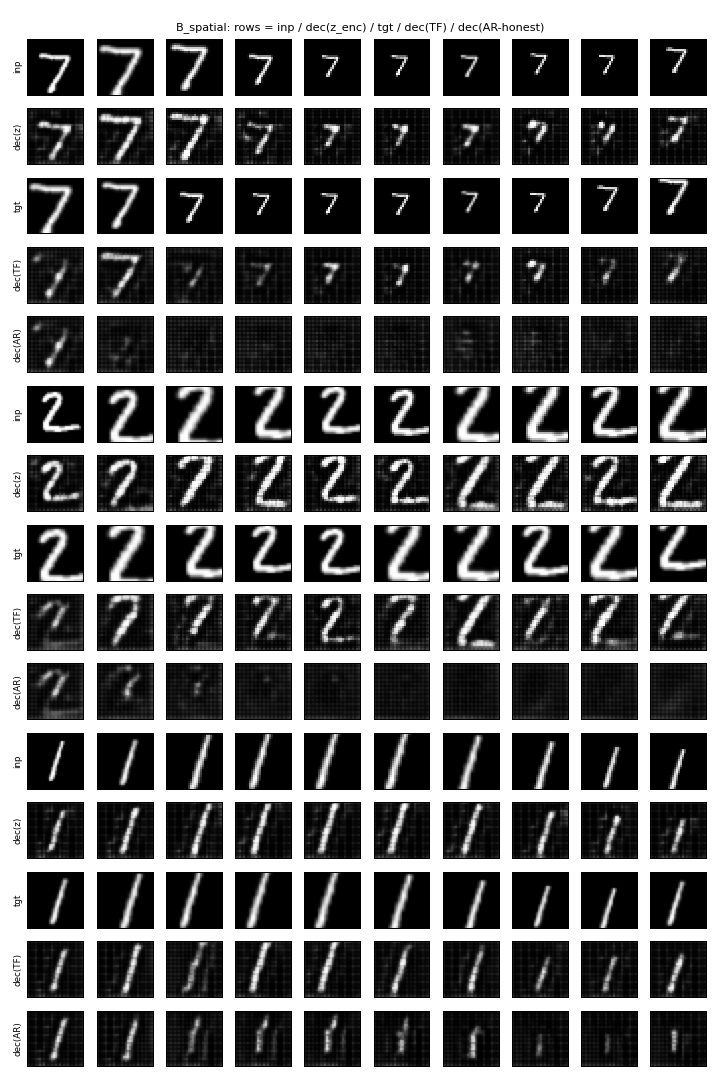

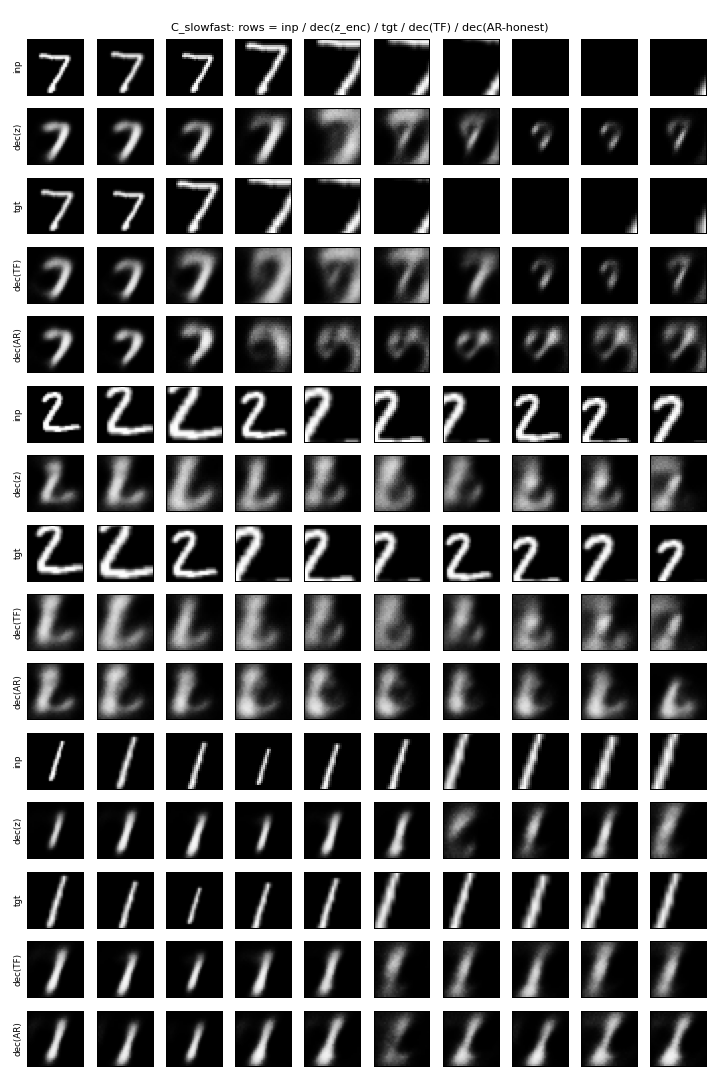

In [5]:
for name in ["baseline", "A_memcontent", "B_spatial", "C_slowfast"]:
    E.plot_rollout(name, packs[name])
    display(Image(f"{E.OUT}/{name}_rollout.png"))


## 5. Takeaways

- **Partial observability is the real ceiling**, confirmed by diagnostics: AR error tracks accumulated
  newly-revealed content, and the true latent is far more decodable than AR predictions.
- **A (memory as content) is the immediate win** — adopt it: it's a tiny, low-risk change to `JEPA.predict`.
- **B and C are research bets**: B needs a stronger/longer-trained decoder and possibly a normalized token
  target; C needs the content code to *update from observations* (here it's frozen in AR) to pay off — that
  is the path toward video / non-affine dynamics where AdaLN handles control and content lives in tokens.
